In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import scipy.stats as sstat
import scipy.signal as ssig

# import ephys_unit_analysis as ena
import mz_ephys_unit_analysis as mz_ena
import mz_unit_dur_freq as mz_udf

import sys
sys.path.append(r'U:/Data_Analysis/kumar603/LemonPy')
from LemonPy.utils_vmk import set_pub_plots
set_pub_plots()

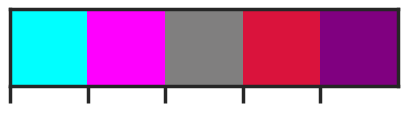

In [2]:
pal=sns.blend_palette(['cyan', 'magenta','gray','crimson','purple'], 5)
sns.palplot(pal)
sns.set_palette(pal)

---

# First, load in the previously saved dataFrames

In [3]:
final_df = pd.read_parquet(r"U:\Papers\FX Behavior paper\data\final_V1HPC_OperantNovel_psth.parquet")
final_df.head()

,stim_id,times,cuid,depth,Hz,zscore,ztc,region,group,cc,et,r_groups,visRes
0,0,0.00,CC067431_HP2_248,740,2.543532,-0.865956,-2.264451,hippo,FX,CC067431,CC067431_HP2,0,yes
1,0,0.01,CC067431_HP2_248,740,2.918449,-0.811714,-1.841745,hippo,FX,CC067431,CC067431_HP2,0,yes
2,0,0.02,CC067431_HP2_248,740,3.278977,-0.759553,-1.435263,hippo,FX,CC067431,CC067431_HP2,0,yes
3,0,0.03,CC067431_HP2_248,740,3.651381,-0.705674,-1.015391,hippo,FX,CC067431,CC067431_HP2,0,yes
4,0,0.04,CC067431_HP2_248,740,4.026938,-0.651339,-0.591964,hippo,FX,CC067431,CC067431_HP2,0,yes


# Now combine the situations

In [4]:
my_region = 'hippo'

region_psth = final_df[final_df.region==my_region]

In [5]:
region_psth.head()

,stim_id,times,cuid,depth,Hz,zscore,ztc,region,group,cc,et,r_groups,visRes
0,0,0.00,CC067431_HP2_248,740,2.543532,-0.865956,-2.264451,hippo,FX,CC067431,CC067431_HP2,0,yes
1,0,0.01,CC067431_HP2_248,740,2.918449,-0.811714,-1.841745,hippo,FX,CC067431,CC067431_HP2,0,yes
2,0,0.02,CC067431_HP2_248,740,3.278977,-0.759553,-1.435263,hippo,FX,CC067431,CC067431_HP2,0,yes
3,0,0.03,CC067431_HP2_248,740,3.651381,-0.705674,-1.015391,hippo,FX,CC067431,CC067431_HP2,0,yes
4,0,0.04,CC067431_HP2_248,740,4.026938,-0.651339,-0.591964,hippo,FX,CC067431,CC067431_HP2,0,yes


# Selecting only the visually responsive units

In [6]:
vis_resp_df = region_psth[region_psth.visRes=='yes']

# Separating by group and situation

In [7]:
group_A_df = vis_resp_df[vis_resp_df['group'] == 'WT']
group_B_df = vis_resp_df[vis_resp_df['group'] == 'FX']

A_rew = group_A_df[group_A_df['stim_id'] == 0]
A_rew2 = group_A_df[group_A_df['stim_id'] == 1]
A_unrew = group_A_df[group_A_df['stim_id'] == 2]
A_novel = group_A_df[group_A_df['stim_id'] == 9]

B_rew = group_B_df[group_B_df['stim_id'] == 0]
B_rew2 = group_B_df[group_B_df['stim_id'] == 1]
B_unrew = group_B_df[group_B_df['stim_id'] == 2]
B_novel = group_B_df[group_B_df['stim_id'] == 9]

# Move to arrays

In [8]:
A_rew_arr = np.array(A_rew.pivot(index='cuid', columns='times', values='zscore'))
A_rew2_arr = np.array(A_rew2.pivot(index='cuid', columns='times', values='zscore'))
A_unrew_arr = np.array(A_unrew.pivot(index='cuid', columns='times', values='zscore'))
A_novel_arr = np.array(A_novel.pivot(index='cuid', columns='times', values='zscore'))

B_rew_arr = np.array(B_rew.pivot(index='cuid', columns='times', values='zscore'))
B_rew2_arr = np.array(B_rew2.pivot(index='cuid', columns='times', values='zscore'))
B_unrew_arr = np.array(B_unrew.pivot(index='cuid', columns='times', values='zscore'))
B_novel_arr = np.array(B_novel.pivot(index='cuid', columns='times', values='zscore'))

---

# Quantifying the oscillation duration and frequency for each situation and group

In [9]:
# first make a function to use on each array
def quantify_duration_freq(input_array, num_cycles_required=2):
    duration = []
    ind = []
    for unit in range(input_array.shape[0]):
        yy = input_array[unit]
        dur, peak_ind = mz_udf._duration_peaks_unit(yy)
        if len(peak_ind) >= num_cycles_required:
            duration.append(dur)
            ind.append(peak_ind)
    
#     ind = np.concatenate(ind, axis=0) #only use this if you want to look at histograms of the peaks
    # otherwise it messes up the freq analysis cells below
    
    return duration, ind

In [10]:
A_rew_dur, A_rew_ind = quantify_duration_freq(A_rew_arr)
A_rew2_dur, A_rew2_ind = quantify_duration_freq(A_rew2_arr)
A_unrew_dur, A_unrew_ind = quantify_duration_freq(A_unrew_arr)
A_novel_dur, A_novel_ind = quantify_duration_freq(A_novel_arr)

B_rew_dur, B_rew_ind = quantify_duration_freq(B_rew_arr)
B_rew2_dur, B_rew2_ind = quantify_duration_freq(B_rew2_arr)
B_unrew_dur, B_unrew_ind = quantify_duration_freq(B_unrew_arr)
B_novel_dur, B_novel_ind = quantify_duration_freq(B_novel_arr)

---

# Duration

In [11]:
def combine_durs(durationA, durationB, stim_id):
    durA_df = pd.DataFrame(tuple(zip(durationA,(['WT']*len(durationA)))),columns=['dur','group'])
    durB_df = pd.DataFrame(tuple(zip(durationB,(['FX']*len(durationB)))),columns=['dur','group'])
    all_dur_df=pd.concat([durA_df,durB_df])
    
    all_dur_df=all_dur_df[~all_dur_df.dur.isna()] #removes any NaN values
    
    all_dur_df['stim_id'] = stim_id
    
    return all_dur_df

In [12]:
rew_dur = combine_durs(A_rew_dur, B_rew_dur, stim_id='rew')
rew2_dur = combine_durs(A_rew2_dur, B_rew2_dur, stim_id='rew2')
unrew_dur = combine_durs(A_unrew_dur, B_unrew_dur, stim_id='unrew')
novel_dur = combine_durs(A_novel_dur, B_novel_dur, stim_id='novel')

all_situation_duration = pd.concat([rew_dur, rew2_dur, unrew_dur, novel_dur])

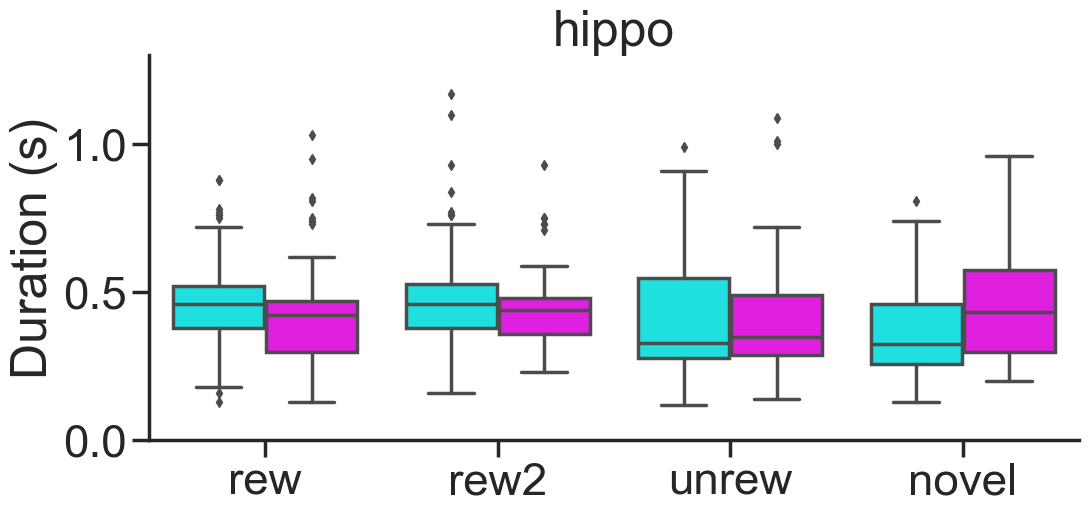

In [14]:
fig,ax=plt.subplots(1,1, figsize=(12,5))
sns.boxplot(data=all_situation_duration, x='stim_id', y='dur', hue='group', dodge=True, ax=ax)

plt.ylabel('Duration (s)')
plt.xlabel('')
plt.title(my_region)
# plt.yticks(ticks=[0.3,0.4,0.5])
plt.ylim([0.0,1.3])
plt.legend([],[],frameon=False)

sns.despine()
# Change the end of this next line with a new file name!!
# plt.savefig(rf'C:\Users\AChub_Lab\Desktop\temp_figures\redo_freq_duration\Allsitu_{my_region}_durationQuant.pdf', transparent=True)

plt.show()

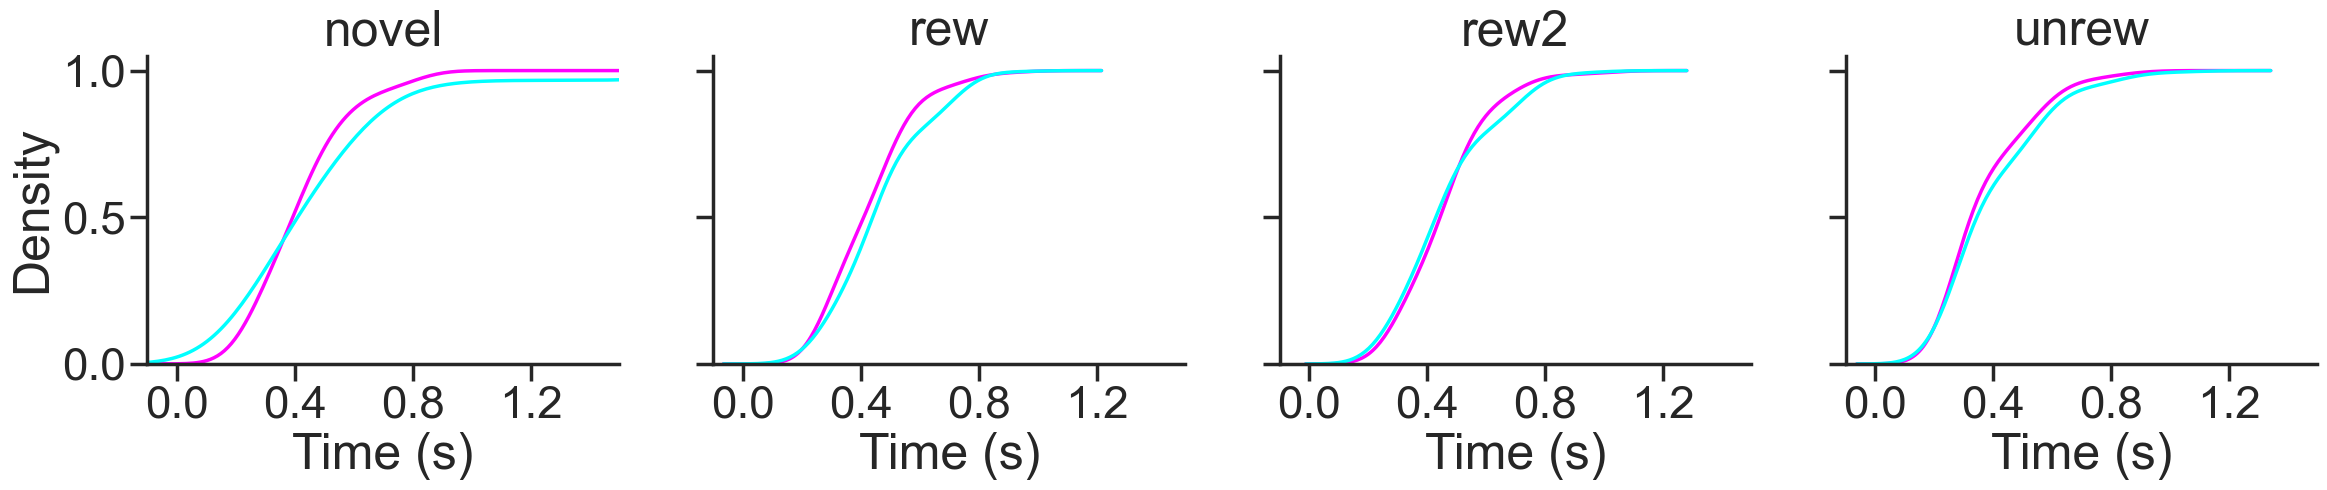

In [21]:
fig,ax = plt.subplots(1,4, sharex=True, sharey=True, figsize=(28,4))
i=0
for d, all_dur_df in all_situation_duration.groupby('stim_id'):
    sns.kdeplot(data=all_dur_df, x="dur", hue="group",
                cumulative=True, common_norm=False, common_grid=True, bw_method=0.5, legend=False, ax=ax[i])
    ax[i].set_title(d)
    ax[i].set_xlabel('Time (s)')
    ax[i].set_xticks([0,0.4,0.8,1.2])
    ax[i].set_xlim([-0.1,1.5])
    i+=1
sns.despine()
# plt.savefig(rf'C:\Users\AChub_Lab\Desktop\temp_figures\Allsitu_{my_region}_durationCDF.pdf', transparent=True)
plt.show()

In [22]:
for d, all_dur_df in all_situation_duration.groupby('stim_id'):
    wt_vals = all_dur_df[all_dur_df['group']=='WT'].dur
    fx_vals = all_dur_df[all_dur_df['group']=='FX'].dur
    result = sstat.ks_2samp(wt_vals, fx_vals)
    print('Oscillation Duration -- 2samp KS test')
    print(d)
    print('WT units: {0} --- FX units: {1}'.format(len(wt_vals),len(fx_vals)))
    print(result)

Oscillation Duration -- 2samp KS test
novel
WT units: 61 --- FX units: 42
KstestResult(statistic=0.15378610460577674, pvalue=0.5354142731203191, statistic_location=0.53, statistic_sign=-1)
Oscillation Duration -- 2samp KS test
rew
WT units: 262 --- FX units: 138
KstestResult(statistic=0.15765018254231664, pvalue=0.019413426406873543, statistic_location=0.41000000000000003, statistic_sign=-1)
Oscillation Duration -- 2samp KS test
rew2
WT units: 199 --- FX units: 134
KstestResult(statistic=0.17047926198154953, pvalue=0.01631876694878733, statistic_location=0.44999999999999996, statistic_sign=1)
Oscillation Duration -- 2samp KS test
unrew
WT units: 193 --- FX units: 136
KstestResult(statistic=0.12141877476379152, pvalue=0.17161683067004682, statistic_location=0.29000000000000004, statistic_sign=-1)


In [23]:
print('Oscillation Duration')
for d, all_dur_df in all_situation_duration.groupby('stim_id'):
    wt_vals = all_dur_df[all_dur_df['group']=='WT'].dur
    fx_vals = all_dur_df[all_dur_df['group']=='FX'].dur
    print(d)
    print('Mean of WT: {0}'.format(np.mean(wt_vals)))
    print('Mean of FX: {0}'.format(np.mean(fx_vals)))
    result = sstat.mannwhitneyu(wt_vals, fx_vals)
    print(result)

Oscillation Duration
novel
Mean of WT: 0.4534426229508197
Mean of FX: 0.41166666666666674
MannwhitneyuResult(statistic=1309.0, pvalue=0.8534974531469046)
rew
Mean of WT: 0.457824427480916
Mean of FX: 0.42101449275362324
MannwhitneyuResult(statistic=19719.0, pvalue=0.13522446792067905)
rew2
Mean of WT: 0.45532663316582905
Mean of FX: 0.45350746268656716
MannwhitneyuResult(statistic=12352.0, pvalue=0.2547256032026973)
unrew
Mean of WT: 0.3897927461139897
Mean of FX: 0.3649264705882353
MannwhitneyuResult(statistic=14522.0, pvalue=0.09946628639900122)


---

# Frequency

In [15]:
def combine_freqs(indA, indB, stim_id):
    mean_freqA = [np.mean(1/np.diff(i)*100)+1 for i in indA]
    mean_freqB = [np.mean(1/np.diff(i)*100)+1 for i in indB]

    freqA_df = pd.DataFrame(tuple(zip(mean_freqA,(['WT']*len(mean_freqA)))),columns=['freq','group'])
    freqB_df = pd.DataFrame(tuple(zip(mean_freqB,(['FX']*len(mean_freqB)))),columns=['freq','group'])
    all_freq_df=pd.concat([freqA_df,freqB_df])

    all_freq_df=all_freq_df[~all_freq_df.freq.isna()] #removes NaN values
    
    all_freq_df['stim_id'] = stim_id
    
    return all_freq_df

In [16]:
rew_freq = combine_freqs(A_rew_ind, B_rew_ind, stim_id='rew')
rew2_freq = combine_freqs(A_rew2_ind, B_rew2_ind, stim_id='rew2')
unrew_freq = combine_freqs(A_unrew_ind, B_unrew_ind, stim_id='unrew')
novel_freq = combine_freqs(A_novel_ind, B_novel_ind, stim_id='novel')

all_situation_frequency = pd.concat([rew_freq, rew2_freq, unrew_freq, novel_freq])

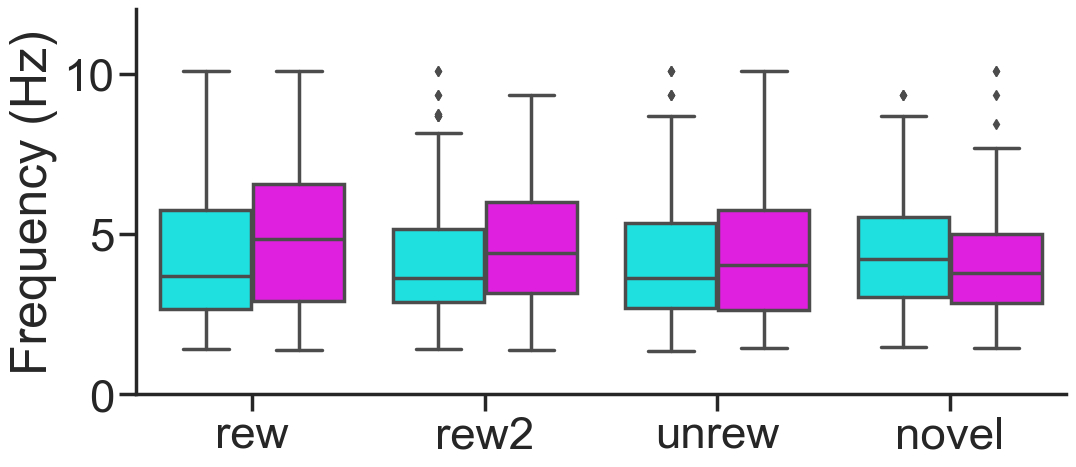

In [18]:
fig,ax=plt.subplots(1,1, figsize=(12,5))
sns.boxplot(data=all_situation_frequency, x='stim_id', y='freq', hue='group', dodge=True, ax=ax)

plt.ylabel('Frequency (Hz)')
plt.xlabel('')
plt.ylim([0,12])
plt.legend([],[],frameon=False)

sns.despine()
# Change the end of this next line with a new file name!!
# plt.savefig(rf'C:\Users\AChub_Lab\Desktop\temp_figures\redo_freq_duration\Allsitu_{my_region}_freqQuant.pdf', transparent=True)

plt.show()

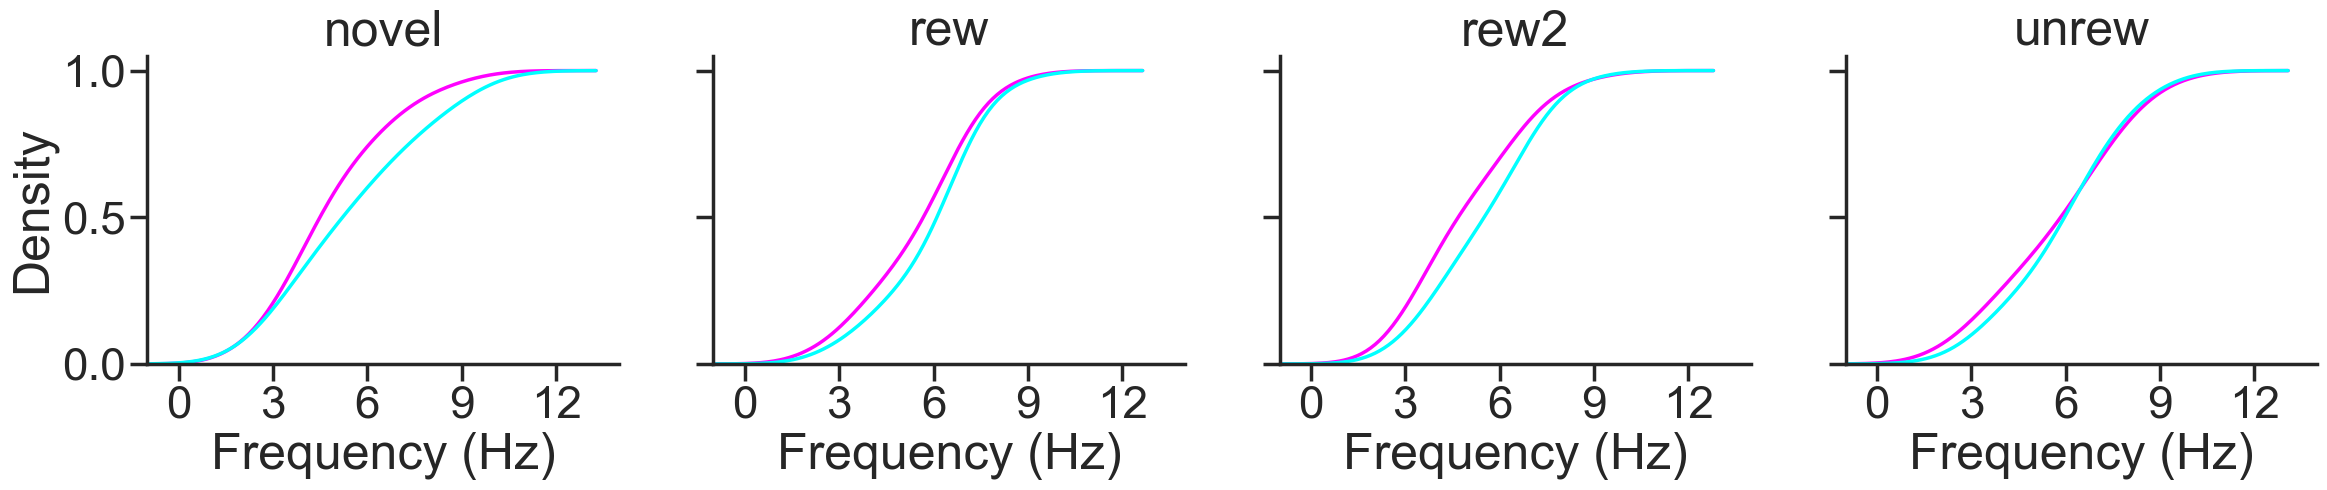

In [29]:
fig,ax = plt.subplots(1,4, sharex=True, sharey=True, figsize=(28,4))
i=0
for d, all_freq_df in all_situation_frequency.groupby('stim_id'):
    sns.kdeplot(data=all_freq_df, x="freq", hue="group",
                cumulative=True, common_norm=False, common_grid=True, bw_method=0.5, legend=False, ax=ax[i])
    ax[i].set_title(d)
    ax[i].set_xlabel('Frequency (Hz)')
    ax[i].set_xticks([0,3,6,9,12])
    ax[i].set_xlim([-1,14])
    i+=1
sns.despine()
# plt.savefig(rf'C:\Users\AChub_Lab\Desktop\temp_figures\Allsitu_{my_region}_frequencyCDF.pdf', transparent=True)
plt.show()

In [30]:
for d, all_freq_df in all_situation_frequency.groupby('stim_id'):
    wt_vals = all_freq_df[all_freq_df['group']=='WT'].freq
    fx_vals = all_freq_df[all_freq_df['group']=='FX'].freq
    result = sstat.ks_2samp(wt_vals, fx_vals)
    print('Oscillation Frequency -- 2samp KS test')
    print(d)
    print('WT units: {0} --- FX units: {1}'.format(len(wt_vals),len(fx_vals)))
    print(result)

Oscillation Frequency -- 2samp KS test
novel
WT units: 101 --- FX units: 123
KstestResult(statistic=0.20132013201320131, pvalue=0.018571198262987556, statistic_location=5.1845456131170415, statistic_sign=-1)
Oscillation Frequency -- 2samp KS test
rew
WT units: 375 --- FX units: 208
KstestResult(statistic=0.12925641025641027, pvalue=0.020407538425825555, statistic_location=5.583333333333333, statistic_sign=-1)
Oscillation Frequency -- 2samp KS test
rew2
WT units: 318 --- FX units: 235
KstestResult(statistic=0.1667603372139703, pvalue=0.000925289322175634, statistic_location=4.492239467849224, statistic_sign=-1)
Oscillation Frequency -- 2samp KS test
unrew
WT units: 261 --- FX units: 207
KstestResult(statistic=0.10211560886223554, pvalue=0.16534995749293974, statistic_location=5.166666666666666, statistic_sign=-1)


In [31]:
print('Oscillation Frequency')
for d, all_freq_df in all_situation_frequency.groupby('stim_id'):
    wt_vals = all_freq_df[all_freq_df['group']=='WT'].freq
    fx_vals = all_freq_df[all_freq_df['group']=='FX'].freq
    print(d)
    print('Mean of WT: {0}'.format(np.mean(wt_vals)))
    print('Mean of FX: {0}'.format(np.mean(fx_vals)))
    # result = sstat.ttest_ind(wt_vals, fx_vals)
    # print(result)
    U,p = sstat.mannwhitneyu(wt_vals, fx_vals)
    print('p =',p)

Oscillation Frequency
novel
Mean of WT: 5.432603646371211
Mean of FX: 4.73939188591724
p = 0.04366025948648165
rew
Mean of WT: 5.8766500026654445
Mean of FX: 5.468687989436328
p = 0.005195249706124929
rew2
Mean of WT: 5.44540967833604
Mean of FX: 4.875418376397575
p = 6.132620080854953e-05
unrew
Mean of WT: 5.866284155569951
Mean of FX: 5.694689120221969
p = 0.5221473898117919
